In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd

We query ZINC22 using the following molecule:

In [3]:
query = Chem.MolFromSmiles("[H]c1c(c(c(c2c1C(=C(N2[H])C(=O)[O-])C([H])([H])C([H])([H])C([H])([H])Oc3c(c(c(c(c3[H])C([H])([H])[H])Cl)C([H])([H])[H])[H])[H])Cl)[H]")
Draw.MolToImage(query)
Draw.MolToFile(query, "query.svg", imageType="svg")

# Analysis of the screening results

We screen ZINC22 using maximum-common substructure with a threshold of 0.4.
The following molecules have been experimentally test. We use the best molecule as the query

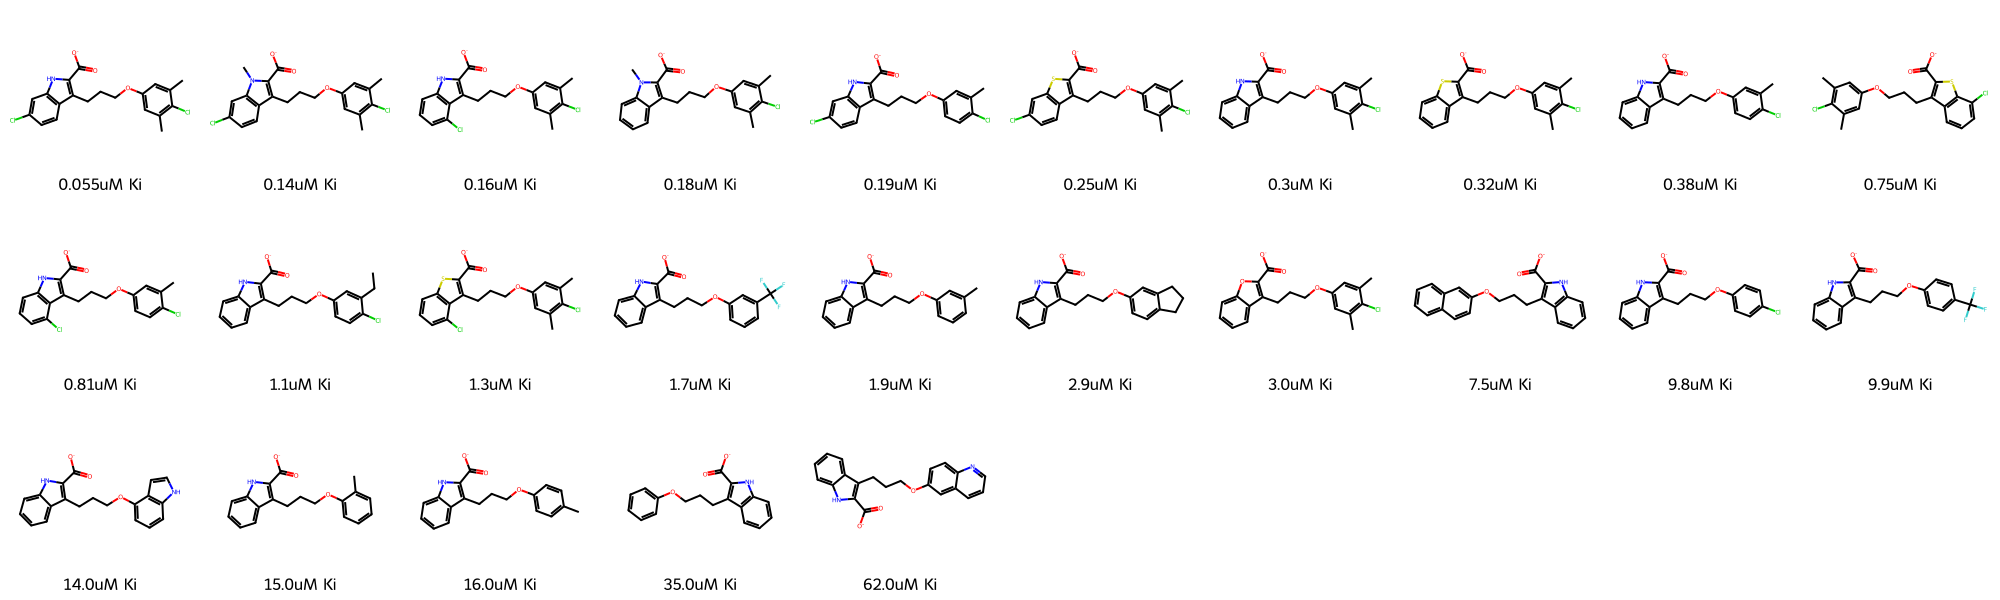

In [14]:
exp_df = pd.read_csv("../data/experimental_results.csv")
exp_df["mols"] = exp_df["smiles"].map(Chem.MolFromSmiles)
exp_df["canon_smiles"] = exp_df["mols"].map(Chem.MolToSmiles)
exp_df = exp_df.sort_values(by="ki")
img = Draw.MolsToGridImage(
    exp_df["mols"], molsPerRow=10, legends=[f"{v}uM Ki" for v in exp_df["ki"]], useSVG=True
)
with open("experimental_binders.svg", "w") as f:
    f.write(img.data)

img

## Screening results

In [8]:
df = pd.read_csv("../screening/similarity_scores.csv", names=["smiles", "similarity"])
df["id"] = df["smiles"].apply(lambda x: x.split("\t")[1])
df["smiles"] = df["smiles"].apply(lambda x: x.split("\t")[0])
df.head()

,smiles,similarity,id
0,OCc1cc2ccccc2[nH]1,0.428571,ZINCbm0000002HYV
1,O=Cc1cc2c([nH]1)CCCC2,0.428571,ZINCbn0000002HZK
2,O=Cc1cc2ccccc2[nH]1,0.428571,ZINCbp0000002HYU
3,CC[C@@H]1CNc2ccccc21,0.428571,ZINCbw0000000Hf4
4,C[C@@H]1Nc2ccccc2[C@H]1C,0.428571,ZINCbw0000000HhK


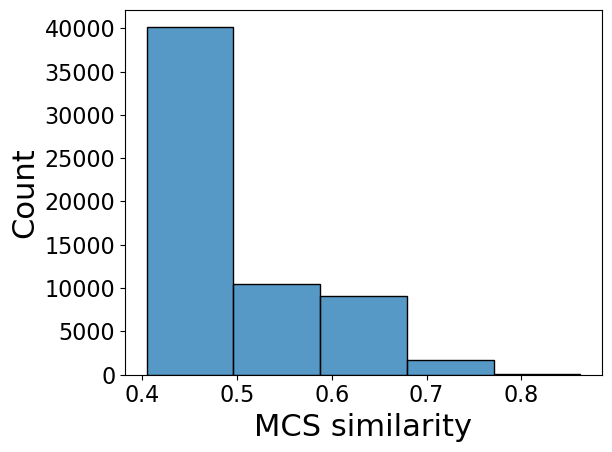

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 22,
    "axes.titlesize": 22
})

g = sns.histplot(df, x="similarity", binwidth=0.1)
g.set_xlabel(
    "MCS similarity",
)

yticks = list(range(0, 45_000, 5_000))
g.set_yticks(yticks)
g.figure.tight_layout()
g.figure.savefig("similarity.svg", format="svg")

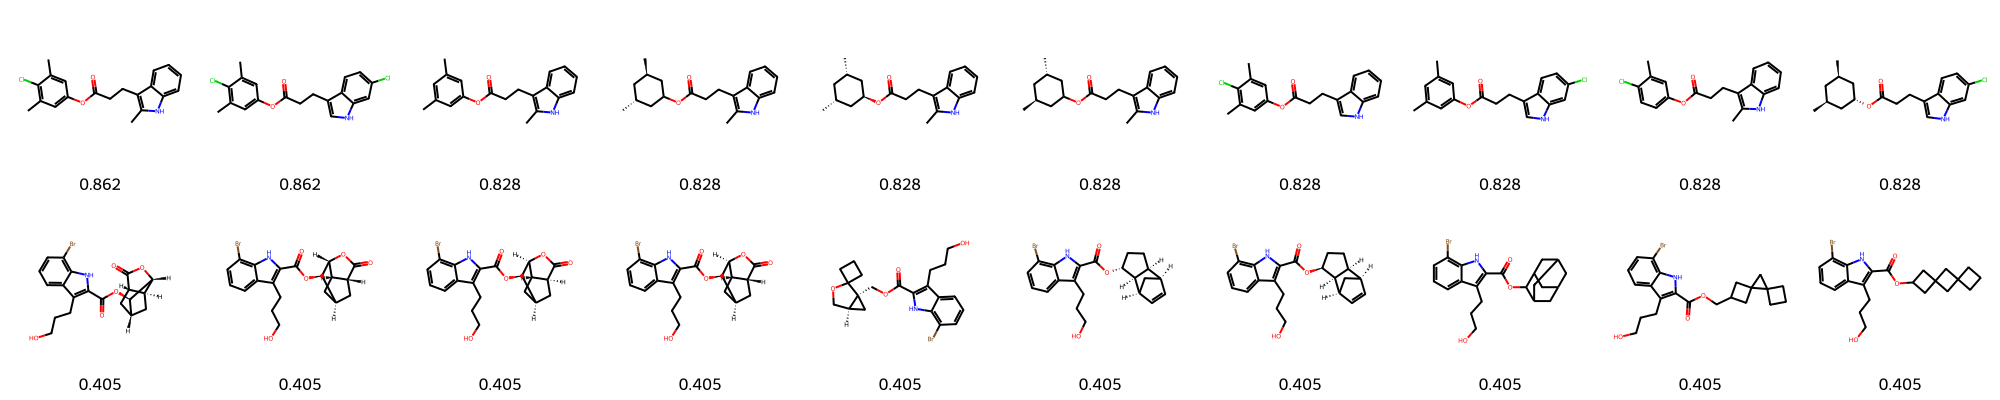

In [21]:
best = df.nlargest(10, columns="similarity")
worst = df.nsmallest(10, columns="similarity")
mols = best["smiles"].map(Chem.MolFromSmiles).tolist() + worst["smiles"].map(Chem.MolFromSmiles).tolist()
sims = [f"{x:.3f}" for x in best["similarity"]] + [f"{x:.3f}" for x in worst["similarity"]]
Draw.MolsToGridImage(
    mols, molsPerRow=10, legends=sims
)

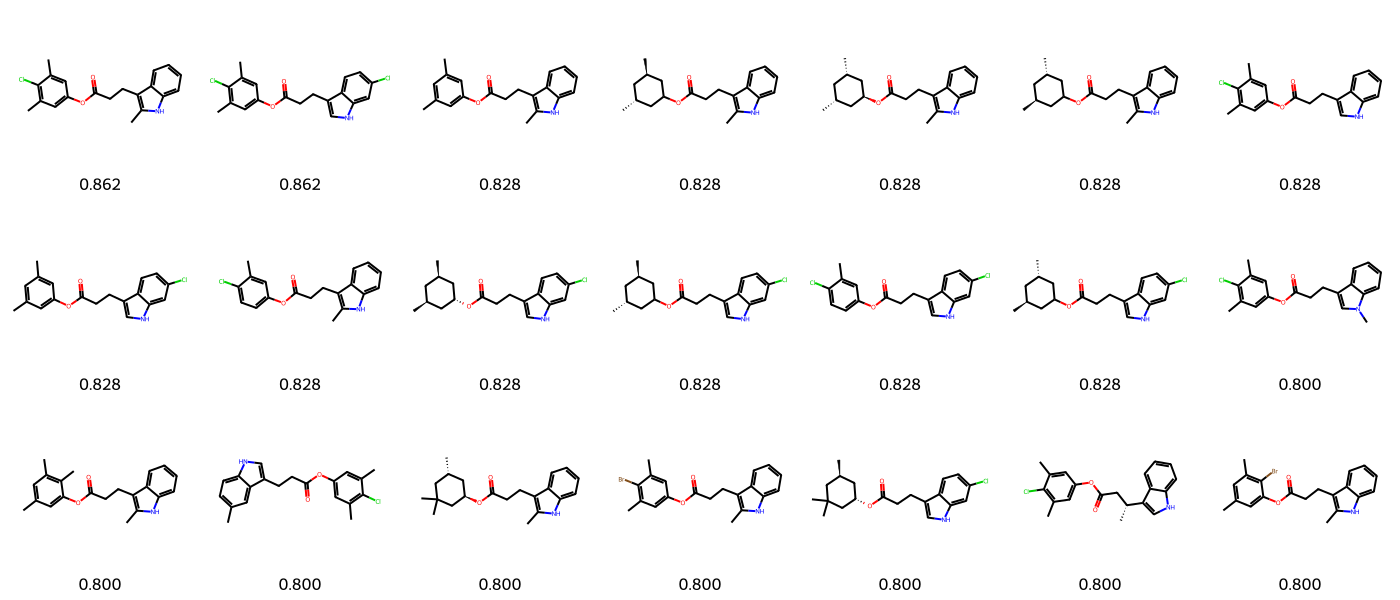

In [10]:
best = df.nlargest(21, columns="similarity")
mols = best["smiles"].map(Chem.MolFromSmiles)
Draw.MolsToGridImage(
    mols, molsPerRow=7, legends=best["similarity"].apply(lambda x: f"{x:.3f}").tolist()
)

Let's further checkout from which tranches of ZINC the molecules are selected

In [11]:
counts_df = pd.read_csv("../screening/tranche_counts.csv", names=["count", "file"])
counts_df["filename"] = counts_df["file"].str.split(".").apply(lambda x: x[0])
counts_df = pd.concat(
    [
        counts_df,
        counts_df["filename"]
        .str.extract("H(\d+)(.\d+)")
        .set_axis(["Heavy atoms", "LogP"], axis="columns"),
    ],
    axis=1,
)
counts_dfp = counts_df.pivot(
    index="LogP", columns="Heavy atoms", values="count"
).fillna(0.0)

<Axes: xlabel='Heavy atoms', ylabel='LogP'>

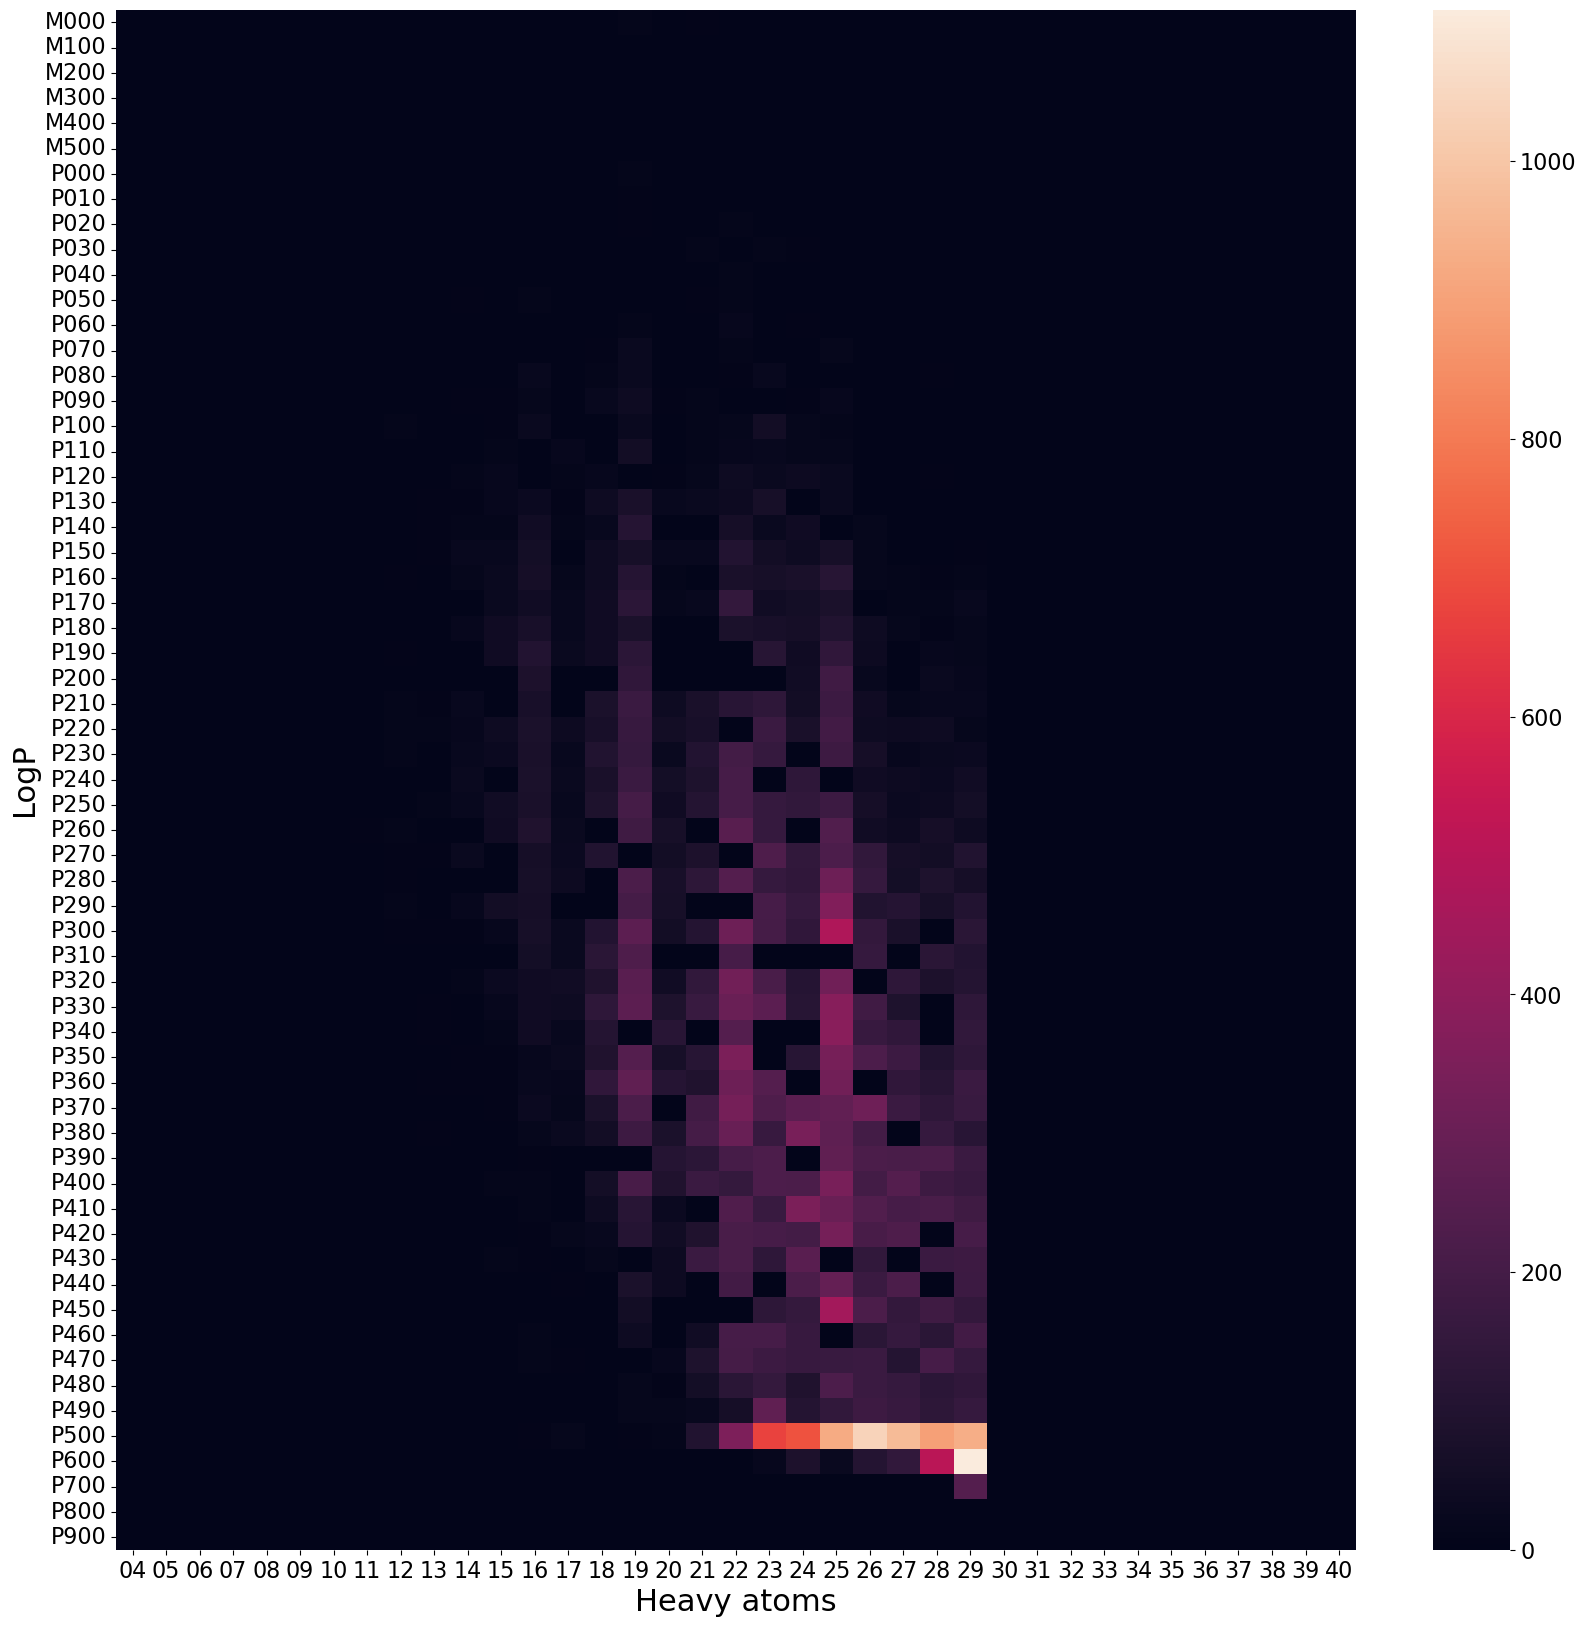

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(counts_dfp, xticklabels=True, yticklabels=True)